## RSI and EWMA
**Strategy:**
This can be viewed as a momentum trading strategy. Using RSI as a indicator one can observe prices continue to have momentum from 50 to lower threshold or 50 to higher threshold then tends to lose steam at the top or at the bottom. Use EWMA smoothing to determine direction.

**Algorithm:**
- Enter Short if closing price is less than EWMA smoothing of the close
    - Stay short if closing price is less than EWMA but look to exit trade on signal
    - Exit signal: If RSI level is less than or equal to lower RSI threshold
    - Exit if position hits 5% loss(In a volatile market loss can be higher by the time trade is executed) 
- Enter Long if closing price is greater than EWMA smoothing of the close
    - Stay Long if closing price is greater than EWMA but look to exit trade on signal
    - Exit signal: If RSI level is greater than or equal to higher RSI threshold
    - Exit if position hits 5% loss(In a volatile market loss can be higher by the time trade is executed)

TA indicators are build using [ta](https://github.com/bukosabino/ta) package which is built with numpy and pandas. For production and depending on frequency other packages may be considered
<p style="color:steelblue; font-weight: bold">Please run the last cell first before starting backtest</p>

In [1]:
import pandas as pd
import numpy as np
import datetime
from datetime import timedelta
#Plotting
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

In [2]:
from ta.trend import MACD
from ta.momentum import RSIIndicator

## Trading data tretment

In [4]:
ticker = "MSTR"
data = pd.read_csv(f"../../../data/{ticker}.5MIN.csv")
# data.set_index("timestamp",inplace=True)
# data.index = pd.to_datetime(data.index)
data['ewma'] = data.close.ewm(min_periods=50, alpha=.1, adjust=True).mean()

## MACD & RSI

In [5]:
df = data.copy()
macd = MACD(close = data.close, window_slow=13, window_fast=5, window_sign=8) #(3, 10, 16)
rsi = RSIIndicator(close = data.close, window=13)
df['MACD'] = macd.macd()
df['SIGNAL'] = macd.macd_signal()
df['HIST'] = macd.macd_diff()
df['HIST_Pos'] = np.where(df['HIST'] >=0, df['HIST'], np.nan)
df['HIST_Neg'] = np.where(df['HIST'] < 0, df['HIST'], np.nan)
df['rsi'] = rsi.rsi()

<Axes: >

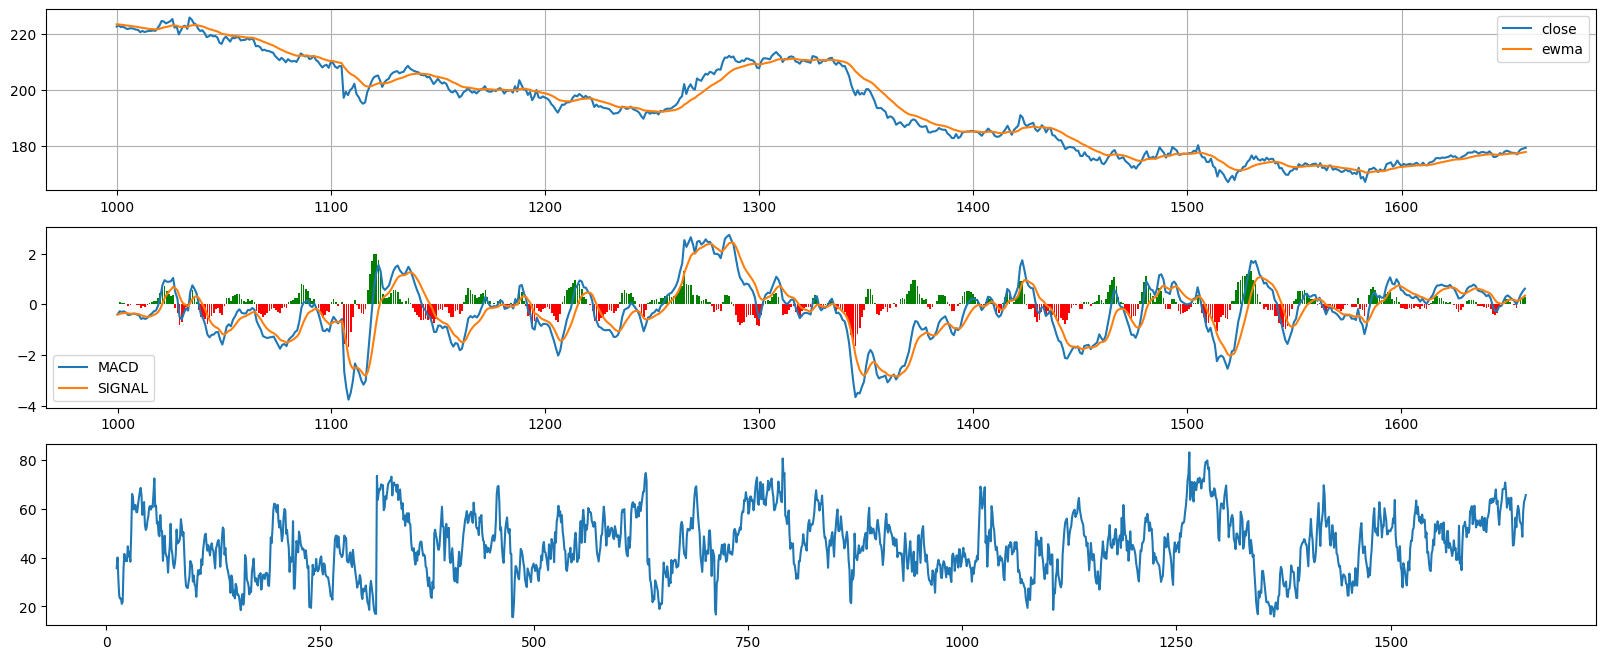

In [6]:
fig, axes = plt.subplots(3,1, figsize=(20,8))
df.loc[1000:,['close', 'ewma']].plot(ax = axes[0])
axes[0].grid()
#MACD
df.loc[1000:,['MACD','SIGNAL']].plot( ax = axes[1])
axes[1].bar(df.loc[1000:].index, df.loc[1000:, 'HIST_Pos'], color="green", label="MACD Hist")
axes[1].bar(df.loc[1000:].index, df.loc[1000:,'HIST_Neg'], color="red", label="MACD Hist")
#RSI
df['rsi'].plot(label="RSI",ax = axes[2])

<h3 style="color:red; font-weight: bold">These are optimized values for RSI/EWMA indicator. Most likely will not work on other tickers or other time frame. Use with caution</h3>

In [8]:
df = RsiEwma(data, rsi_window=5, rsi_upper=72, rsi_lower=9)

## Plot the trades

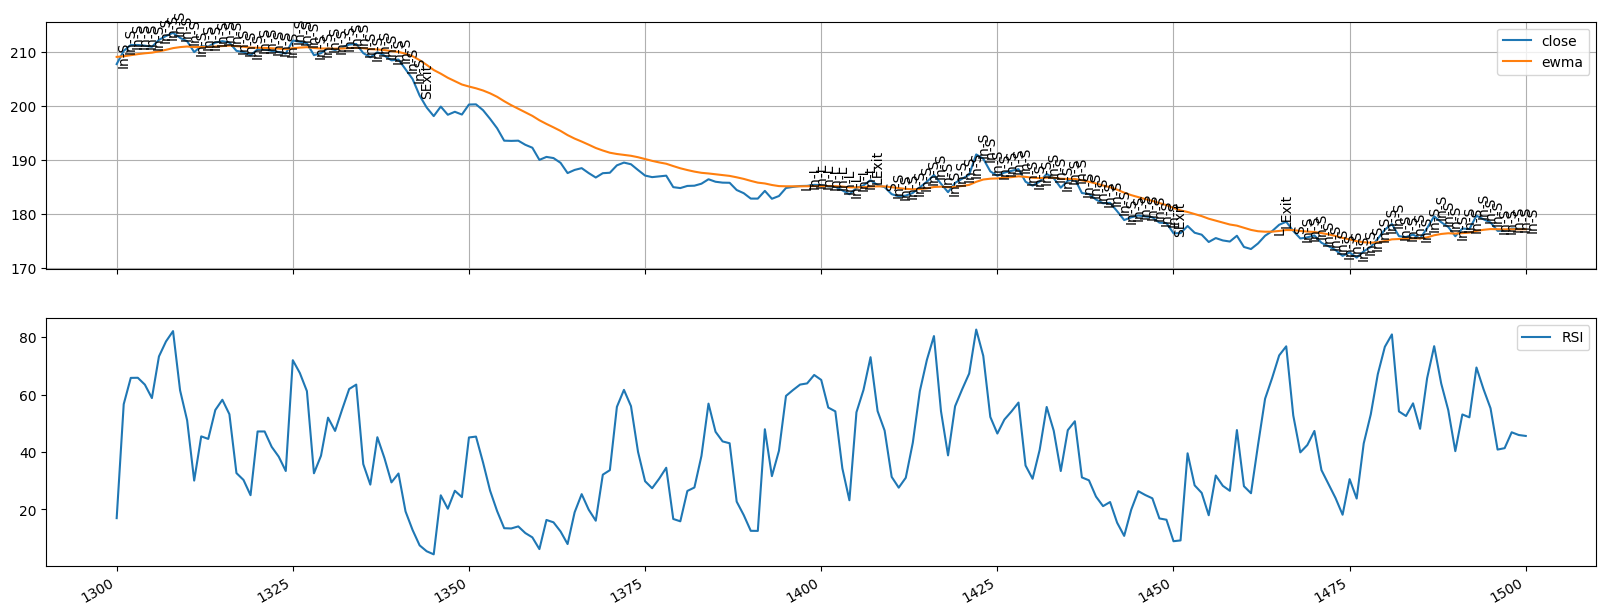

In [17]:
# as_of_date = 1500
temp = df.loc[1300:1500]
fig, axes = plt.subplots(2,1, figsize=(20,8))
temp[['close', 'ewma']].plot(ax = axes[0])
axes[0].grid()
#RSI
temp['rsi'].plot(label="RSI",ax = axes[1])

# #Add the text
text_column = temp.columns.tolist().index("Trade")
# for i in range(len(temp)):
#     axes[0].text(i, temp.iat[i, 3], temp.iat[i, text_column])
for index, row in temp.iterrows():
    axes[0].text(index, temp.at[index, 'close'], temp.at[index, 'Trade'], rotation_mode="default", rotation=90)
    
fig.autofmt_xdate() # automatically formats the x-axis labels
axes[0].legend()
axes[1].legend()
plt.show()

<Axes: title={'center': 'Cumulative PnL'}>

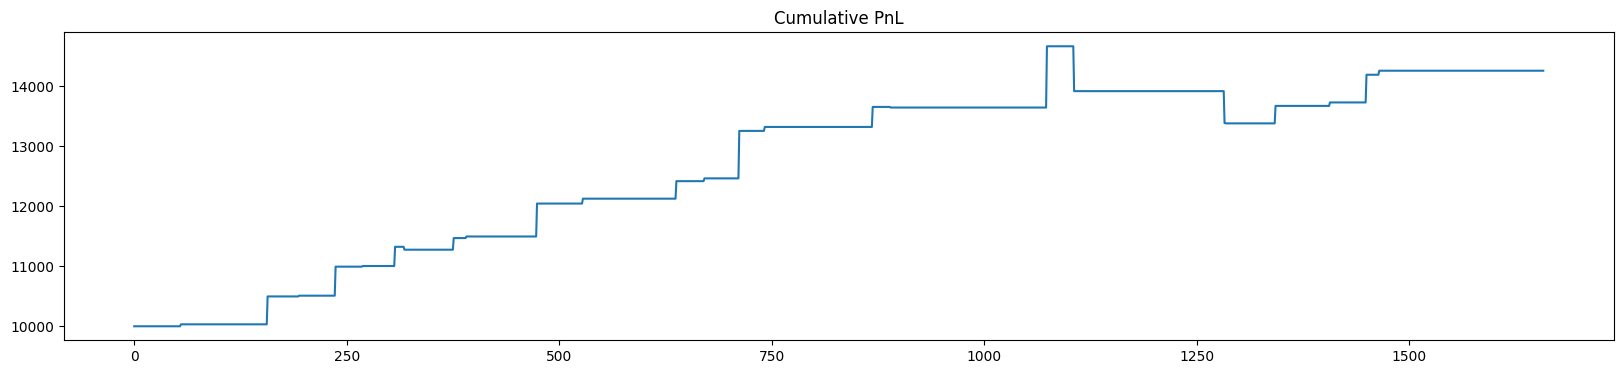

In [18]:
df['CumuPnL'].plot(figsize = (20,4), title="Cumulative PnL")

In [19]:
cum_ret = (df['CumuPnL'].pct_change() + 1).cumprod()
last_peak_return = cum_ret[cum_ret.values == cum_ret.max()].index[-1]
peak = cum_ret.max()
trough = cum_ret.loc[last_peak_return:].min()
max_dd = (trough-peak)/peak

metrics = {
    "Total PnL" : f"{df['PnL'].sum():,.1f}",
    "Wins": df[df['PnL'] > 0].shape[0],
    "Losses": df[df['PnL'] < 0].shape[0],
    "Wins PnL": f"{df[df['PnL'] > 0]['PnL'].sum() : ,.1f}",
    "Losses PnL": f"{df[df['PnL'] < 0]['PnL'].sum() : ,.1f}",
    "Win Ratio": f"{df[df['PnL'] > 0].shape[0] / df['Trade'].value_counts()[['LExit','SExit']].sum() : .1%}",
    "Total Trades": df['Trade'].value_counts()[['LExit','SExit']].sum(),
    "Average PnL" : f"{df['PnL'].sum()/df['Trade'].value_counts()[['LExit','SExit']].sum() : ,.1f}",
    "Max Drawdown": f"{max_dd : .1%}",
    "Annualized Mean Return": f"{df['CumuPnL'].pct_change().mean() * 4 * 24 * 252 : ,.1%}"
}

In [77]:
pd.DataFrame.from_dict(metrics,orient="index").T

,Total PnL,Wins,Losses,Wins PnL,Losses PnL,Win Ratio,Total Trades,Average PnL,Max Drawdown,Annualized Mean Return
0,"4,261.0",20,5,"5,605.3","-1,344.3",87.0%,23,185.3,-8.8%,535.3%


In [7]:
#---------------------------------------------------------------------------------------------------------------#
# Enter short when P Band < 0.5. close < medium band. Exit when P Band < .2[or optimized value]                 #
# Enter long when P Band > 0.5. close > medium band.  Exit when P Band > .8[or optimized value]                 #
# This flips flops. If there was a short trade then there would be a long trade. So forth and so on             #
#---------------------------------------------------------------------------------------------------------------#
def RsiEwma(temp_df, rsi_window=5, rsi_upper=80, rsi_lower=20):
    df = data.copy()
    rsi = RSIIndicator(close = data.close, window=rsi_window)
    df['rsi'] = rsi.rsi()
    short = False
    long = False
    enter_price = 0
    df['Trade'] = ""
    df['PnL'] = 0.0
    counter = 1
    shares_traded = 0
    notional = 10000
    exit_signal = None
    was_in_long = False
    was_in_short = False
    for row in df.itertuples(index=True):
        if counter > rsi_window:        
            if short == False and long == False:            
                if was_in_short == False and row.close < row.ewma:
                    enter_price = row.close
                    shares_traded = round(notional/row.close, 0)
                    short = True
                    df.at[row.Index, 'Trade'] = "S"
                elif was_in_long == False and row.close > row.ewma:
                    enter_price = row.close
                    shares_traded = round(notional/row.close, 0)
                    long = True
                    df.at[row.Index, 'Trade'] = "L"
                else:
                    pass
            else:
                #We are in a trade
                if short:
                    #Close position due to risk management
                    if ( shares_traded*(enter_price - row.close) / notional ) < -0.05:   
                        df.at[row.Index, 'PnL'] = shares_traded*(enter_price - row.close)          
                        df.at[row.Index, 'Trade'] = "SExitR"
                        short = False
                        shares_traded = 0
                        was_in_short = True
                        was_in_long = False
                    #Stay in trade if we are in the right direction
                    elif row.close < row.ewma:
                        df.at[row.Index, 'Trade'] = "In-S" #Just mark we are in short position
                        exit_signal = True
                    else:                    
                        df.at[row.Index, 'Trade'] = "In-S" #Just mark we are in short position
                    
                    if exit_signal == True:
                        if row.rsi <= rsi_lower:
                            df.at[row.Index, 'PnL'] = shares_traded*(enter_price - row.close) #Short PnL                    
                            df.at[row.Index, 'Trade'] = "SExit"
                            short = False
                            shares_traded = 0
                            exit_signal = False
                            was_in_short = True
                            was_in_long = False
                elif long:
                    if ( shares_traded*(row.close - enter_price) / notional ) < -0.05: #Close Position Risk Management  
                        df.at[row.Index, 'PnL'] = shares_traded*(row.close - enter_price)               
                        df.at[row.Index, 'Trade'] = "LExitR"
                        long = False
                        shares_traded = 0
                        was_in_long = True
                        was_in_short = False
                    #Stay in trade if we are in the right direction
                    elif row.close > row.ewma:
                        df.at[row.Index, 'Trade'] = "In-L"
                        exit_signal = True
                    else:
                        df.at[row.Index, 'Trade'] = "In-L"
                    
                    if exit_signal == True:
                        if row.rsi >= rsi_upper:
                            df.at[row.Index, 'PnL'] = shares_traded*(row.close - enter_price) #Long PnL
                            df.at[row.Index, 'Trade'] = "LExit"
                            long = False
                            shares_traded = 0
                            exit_signal = False
                            was_in_long = True
                            was_in_short = False
                else:
                    pass
        
        counter +=1 #increment
    
    df['CumuPnL'] = df['PnL']
    df.loc[df.index[0], 'CumuPnL'] = 10000 #Initial investment
    df['CumuPnL'] = df['CumuPnL'].cumsum()
    return df

### This is a good start, however, there are some things to consider
- Technical analysis rarely ever works out of the box because the parameters change over time because the backtest had constant parameters for RSI throughout the time series.
- Where future information incorrectly influences past trading decisions, resulting in unrealistic performance
- The backtest actually has a look ahead bias, again because of the parameters because in real time we only know the parameters that worked best in past.